In [2]:
# import requests
import pandas as pd
import numpy as np
# from scipy.stats import entropy
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf#, plot_pacf
# from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          

# import holidays

# pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [3]:
df = pd.read_csv("dataset_FINAL_all_variables.csv")

In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')


In [6]:
df.columns

Index(['workforce', 'inactives', 'employment_rate', 'youth_employment_rate',
       'activity_rate', 'unemployment_rate', 'industry_production_prices',
       'companies_trust', 'gasoline_car_price', 'diesel_price', 'GPL_price',
       'diesel_heatining_price', 'workforce_diff', 'inactives_diff',
       'employment_rate_diff', 'youth_employment_rate_diff',
       'activity_rate_diff', 'unemployment_rate_diff',
       'industry_production_prices_diff', 'gasoline_car_price_diff',
       'diesel_price_diff', 'diesel_heatining_price_diff', 'covid_period',
       'ukraine_war', 'PCA_labour_market_1', 'PCA_labour_market_2',
       'PCA_macroeconomic_variables_1', 'PCA_macroeconomic_variables_2',
       'PCA_price_energy_1', 'PCA_price_energy_2', 'lag_12m', 'lag_1m',
       'lag_2m', 'lag_3m', 'rolling_mean_12m', 'rolling_mean_3m',
       'rolling_mean_6m', 'rolling_std_12m'],
      dtype='str')

In [ ]:
selected_cols = [
        #  'Anno'
        # , 'Mese'
         #  'GDPGrowth'
      #   , 'companies_trust'
         # 'GPL_price'
       , 'fixed_term'
      #  , 'permanent'
      #  , 'workforce'
      #  , 'inactives'
       , 'employment_rate'
       , 'youth_employment_rate'
      #  , 'activity_rate'
      #  , 'unemployment_rate'
       , 'industry_production_prices'
      #  , 'gasoline_car_price'
       , 'diesel_price'
       ]

In [69]:
df_selected = df[selected_cols]
df_selected.head(5)

,WorkingDays,fixed_term,employment_rate,youth_employment_rate,industry_production_prices,diesel_price,TotSales
date,,,,,,,
2014-02-01,20,2116627,38.64,54.49,93.0,1.63783,78038658
2014-03-01,21,2188435,38.81,55.42,92.8,1.63147,84094082
2014-04-01,20,2215274,37.57,54.69,92.6,1.62855,86341669
2014-05-01,21,2255743,39.78,55.44,92.5,1.63068,90493760
2014-06-01,20,2436989,39.38,55.90,92.7,1.63208,90851778


# 1. Fixed Term

## Training

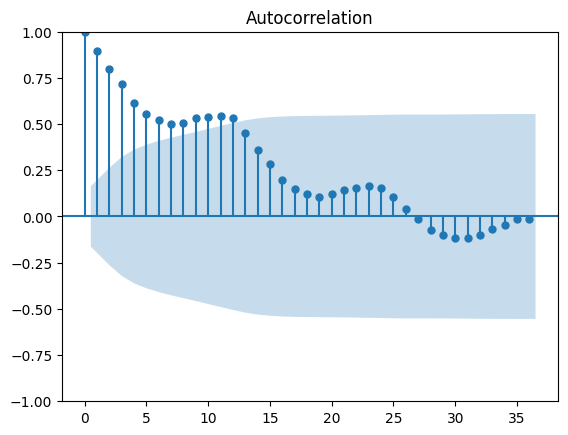

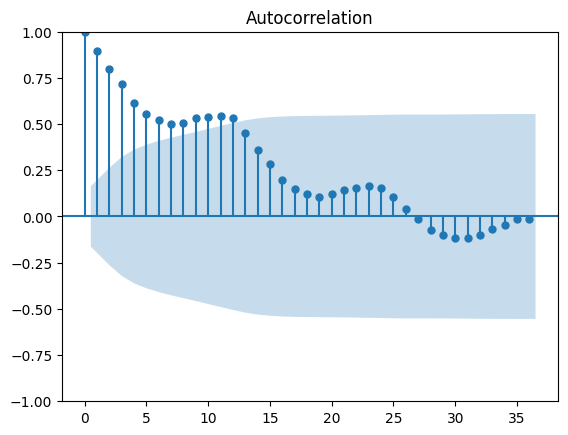

In [70]:
feature = 'fixed_term'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

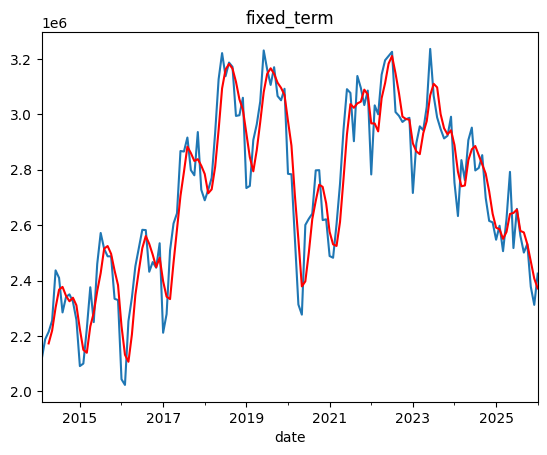

In [72]:
plt.title(feature)
rolling = df[feature].rolling(window=3) #df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
plt.show()

In [73]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 13))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [74]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 93317.55
mae_test: 181485.05
mape_train: 0.03%
mape_test: 0.07%


### Forecasting

In [75]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 1))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_fixed_term = pd.DataFrame({f"{feature}": fcst})
df_fcst_fixed_term

,fixed_term
2026-02-01,2.636238e+06
2026-03-01,2.714841e+06
2026-04-01,2.714841e+06
2026-05-01,2.714841e+06
2026-06-01,2.714841e+06
2026-07-01,2.714841e+06
2026-08-01,2.714841e+06
2026-09-01,2.714841e+06
2026-10-01,2.714841e+06
2026-11-01,2.714841e+06


In [76]:
# df_selected = pd.concat([df_selected, df_fcst], axis = 0)
# df_selected

# 2. employment_rate

### Training

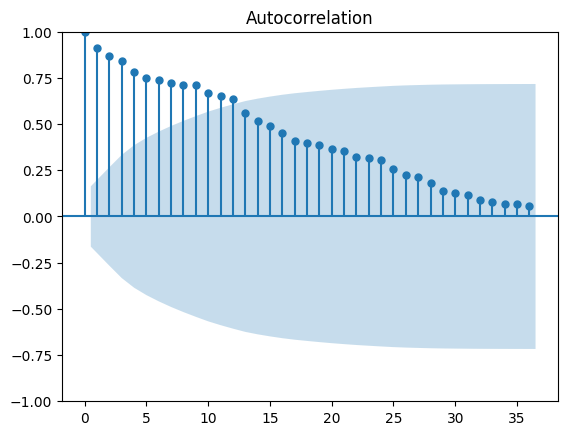

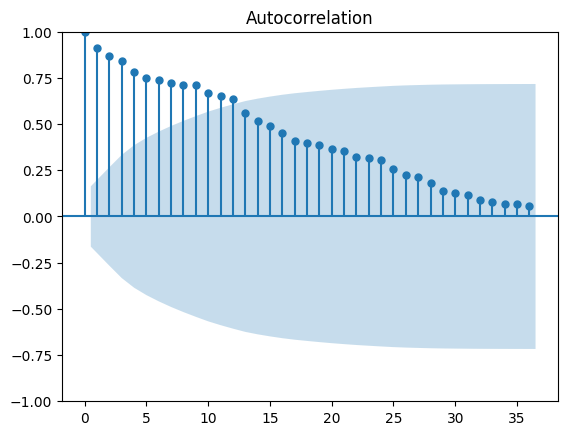

In [77]:
feature = 'employment_rate'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

In [78]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-1.79 > -2.88 ==> The time series is NON stationary


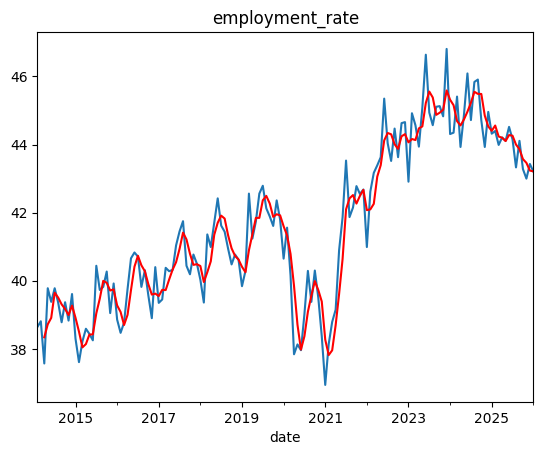

In [79]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [80]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 13))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [81]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.68
mae_test: 0.75
mape_train: 0.02%
mape_test: 0.02%


### Forecasting

In [82]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 13))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_employment_rate = pd.DataFrame({f"{feature}": fcst})
df_fcst_employment_rate

,employment_rate
2026-02-01,43.338540
2026-03-01,42.885524
2026-04-01,43.001046
2026-05-01,42.400337
2026-06-01,42.585850
2026-07-01,42.621689
2026-08-01,41.996470
2026-09-01,42.352375
2026-10-01,42.138284
2026-11-01,42.010220


# 3. youth_employment_rate

### Training

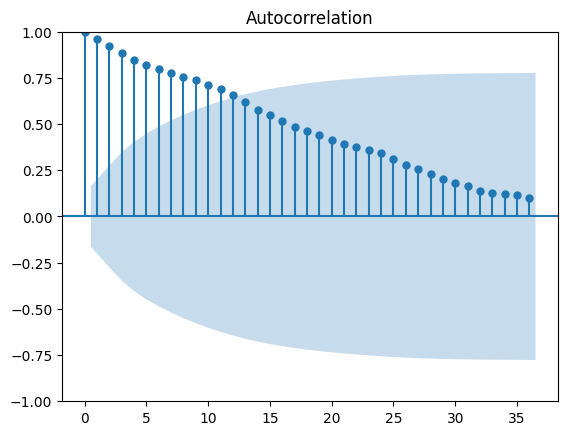

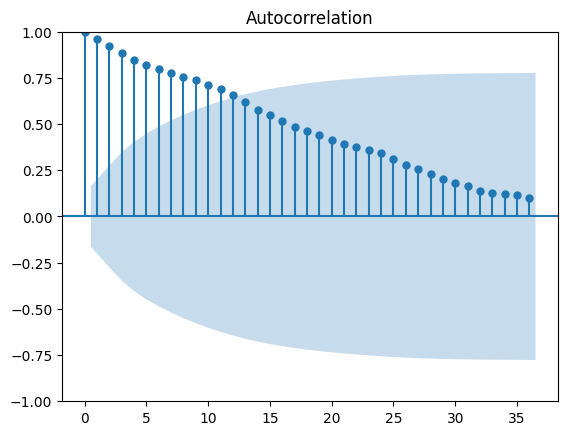

In [83]:
feature = 'youth_employment_rate'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

In [84]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-1.09 > -2.88 ==> The time series is NON stationary


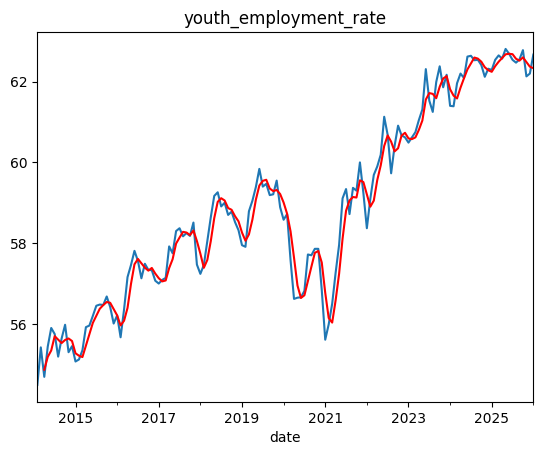

In [85]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [86]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 12))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [87]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.41
mae_test: 2.35
mape_train: 0.01%
mape_test: 0.04%


### Forecasting

In [22]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_youth_employment_rate = pd.DataFrame({f"{feature}": fcst})
df_fcst_youth_employment_rate

,youth_employment_rate
2026-02-01,62.449866
2026-03-01,62.044107
2026-04-01,61.789375
2026-05-01,61.492910
2026-06-01,60.923601
2026-07-01,60.524022
2026-08-01,60.096764
2026-09-01,59.791876
2026-10-01,59.567008
2026-11-01,59.134016


# 4. industry_production_prices

### Training

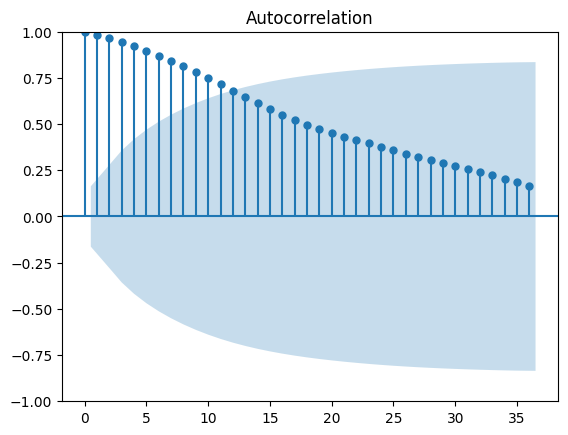

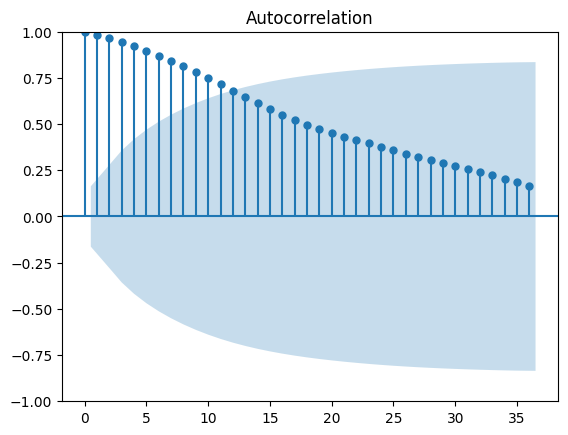

In [23]:
feature = 'industry_production_prices'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 )

In [ ]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

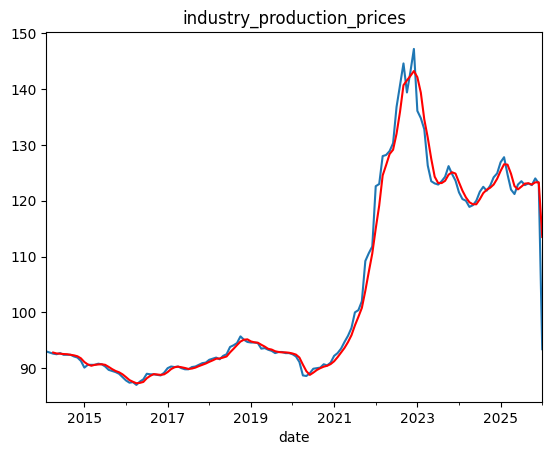

In [24]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [25]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 12))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [26]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 1.69
mae_test: 5.2
mape_train: 0.02%
mape_test: 0.04%


### Forecasting

In [27]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_industry_production_prices = pd.DataFrame({f"{feature}": fcst})
df_fcst_industry_production_prices

,industry_production_prices
2026-02-01,83.158880
2026-03-01,85.034267
2026-04-01,86.590718
2026-05-01,91.066334
2026-06-01,95.521394
2026-07-01,96.130949
2026-08-01,95.214299
2026-09-01,90.845594
2026-10-01,87.277491
2026-11-01,86.179745


# 5. diesel_price

### Training

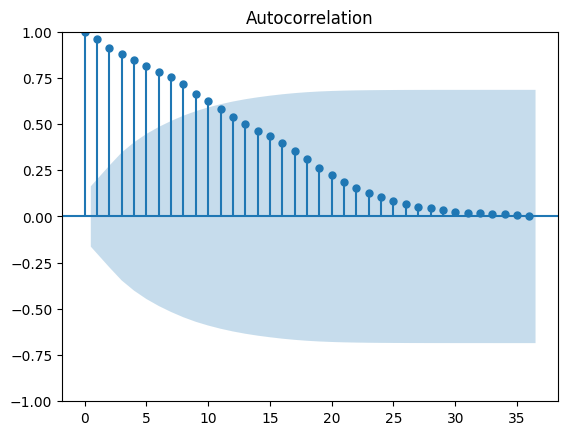

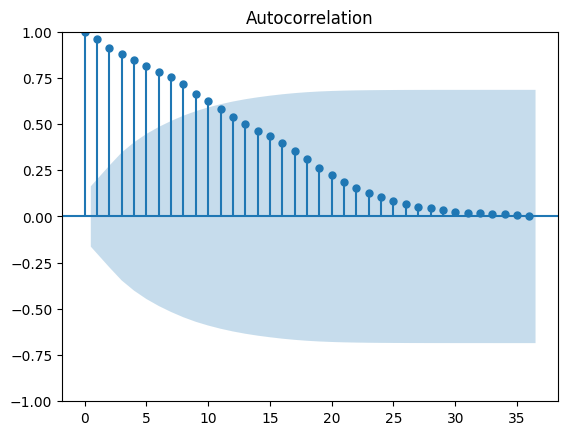

In [28]:
feature = 'diesel_price'

width = 10
height = 5

plot_acf(df[feature],lags=36,alpha=0.05 ) 

In [ ]:
test_staticist = adfuller(df[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df[f'{feature}_diff'] = df[feature] - df[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

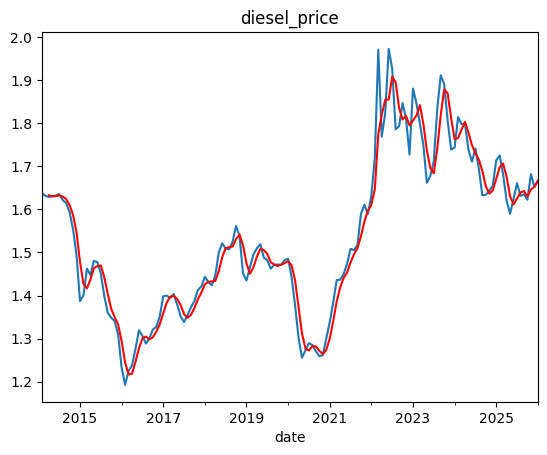

In [29]:
from matplotlib import pyplot
#series = read_csv('daily-total-female-births.csv', header=0, index_col=0)
# Tail-rolling average transform
plt.title(feature)
rolling = df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df[feature].plot()
rolling_mean.plot(color='red')
pyplot.show()

In [30]:
df_train = df[feature][5:-12]
df_test = df[feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 11))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [31]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.03
mae_test: 0.07
mape_train: 0.02%
mape_test: 0.04%


### Forecasting

In [32]:
h = 12
model = ARIMA( endog=df[feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_diesel_price = pd.DataFrame({f"{feature}": fcst})
df_fcst_diesel_price

,diesel_price
2026-02-01,1.689318
2026-03-01,1.676623
2026-04-01,1.661880
2026-05-01,1.670270
2026-06-01,1.662256
2026-07-01,1.655987
2026-08-01,1.616661
2026-09-01,1.617648
2026-10-01,1.582382
2026-11-01,1.569952


# GENERATE FINAL DATASET

# Working days

In [33]:
year = 2026

# Italy holidays
it_holidays = holidays.country_holidays("IT", years=[year])

# Generate all days in the year
# dates = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31")
dates = pd.date_range(start="2026-01-01", end="2027-01-31")

df_days = pd.DataFrame({"date": dates})

# Weekday: Monday=0, Sunday=6
df_days["weekday"] = df_days["date"].dt.weekday

df_days["month_start"] = df_days["date"] - pd.offsets.MonthBegin(1) + pd.offsets.MonthBegin(0)

# Working day if weekday < 5 and not a holiday
df_days["is_working_day"] = (df_days["weekday"] < 5) & (~df_days["date"].isin(it_holidays))

# Count working days per month
monthly_working_days = df_days.groupby(df_days["date"].dt.month)["is_working_day"].sum()

df_days['WorkingDays'] = np.where(df_days['is_working_day']==True, 1, 0)

In [34]:
df_working_days = df_days[df_days['month_start']>'2026-01-01'].groupby('month_start')['WorkingDays'].sum().reset_index().rename(columns={'month_start':'date'}).set_index('date')


In [35]:
df_working_days

,WorkingDays
date,
2026-02-01,20
2026-03-01,23
2026-04-01,20
2026-05-01,21
2026-06-01,21
2026-07-01,22
2026-08-01,22
2026-09-01,22
2026-10-01,21


In [36]:
df_fcst = pd.concat([df_fcst_fixed_term, 
                     df_fcst_employment_rate,
                     df_fcst_youth_employment_rate, 
                     df_fcst_industry_production_prices,
                     df_fcst_diesel_price, 
                     df_working_days], axis = 1)
df_fcst

,fixed_term,employment_rate,youth_employment_rate,industry_production_prices,diesel_price,WorkingDays
2026-02-01,2.636238e+06,43.338540,62.449866,83.158880,1.689318,20
2026-03-01,2.714841e+06,42.885524,62.044107,85.034267,1.676623,23
2026-04-01,2.714841e+06,43.001046,61.789375,86.590718,1.661880,20
2026-05-01,2.714841e+06,42.400337,61.492910,91.066334,1.670270,21
2026-06-01,2.714841e+06,42.585850,60.923601,95.521394,1.662256,21
2026-07-01,2.714841e+06,42.621689,60.524022,96.130949,1.655987,22
2026-08-01,2.714841e+06,41.996470,60.096764,95.214299,1.616661,22
2026-09-01,2.714841e+06,42.352375,59.791876,90.845594,1.617648,22
2026-10-01,2.714841e+06,42.138284,59.567008,87.277491,1.582382,21
2026-11-01,2.714841e+06,42.010220,59.134016,86.179745,1.569952,22


In [37]:
df_selected = pd.concat([df_selected, df_fcst], axis = 0)
df_selected

,WorkingDays,fixed_term,employment_rate,youth_employment_rate,industry_production_prices,diesel_price,TotSales
2014-02-01,20,2.116627e+06,38.640000,54.490000,93.000000,1.637830,78038658.0
2014-03-01,21,2.188435e+06,38.810000,55.420000,92.800000,1.631470,84094082.0
2014-04-01,20,2.215274e+06,37.570000,54.690000,92.600000,1.628550,86341669.0
2014-05-01,21,2.255743e+06,39.780000,55.440000,92.500000,1.630680,90493760.0
2014-06-01,20,2.436989e+06,39.380000,55.900000,92.700000,1.632080,90851778.0
...,...,...,...,...,...,...,...
2026-09-01,22,2.714841e+06,42.352375,59.791876,90.845594,1.617648,NaN
2026-10-01,21,2.714841e+06,42.138284,59.567008,87.277491,1.582382,NaN
2026-11-01,22,2.714841e+06,42.010220,59.134016,86.179745,1.569952,NaN
2026-12-01,21,2.714841e+06,41.981760,58.987024,79.987429,1.551591,NaN


In [ ]:
df_selected.to_csv('italy_revenues_PREDICTION_DATASET.csv')